# 🌍 Clasificador de Sentimientos — Comentarios Mundial 2026
## Naive Bayes Multinomial + Bag of Words

---

Este notebook muestra **paso a paso cómo decide el modelo** si un comentario es Positivo, Neutral o Negativo.  
Cada sección tiene una visualización que hace visible la matemática detrás del algoritmo.

> 🎨 **Paleta de colores usada en todo el notebook:**
> - 🔴 `#E74C3C` → **Negativo**
> - ⚫ `#95A5A6` → **Neutral**  
> - 🟢 `#27AE60` → **Positivo**

In [22]:
# ══════════════════════════════════════════════════════════════════════
# CELDA DE CONFIGURACIÓN — ejecutar PRIMERO antes de cualquier otra
# Carga librerías, dataset, entrena los modelos y define colores
# ══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ── Paleta de colores ─────────────────────────────────────────────────
COLORES = {
    'Negativo': '#E74C3C',
    'Neutral':  '#95A5A6',
    'Positivo': '#27AE60',
}
CLASES_ORDEN  = ['Negativo', 'Neutral', 'Positivo']
LISTA_COLORES = [COLORES[c] for c in CLASES_ORDEN]

# ── Cargar dataset ────────────────────────────────────────────────────
df = pd.read_csv('dataset_mundial2026.csv')
X_texto = df['comentario']
y       = df['sentimiento']
print(f'Dataset cargado: {len(df)} comentarios')
print(df['sentimiento'].value_counts())

# ── Vectorización ─────────────────────────────────────────────────────
STOP_WORDS_ES = [
    'el','la','los','las','un','una','unos','unas','de','del','al',
    'en','y','o','que','con','por','para','es','fue','fueron','ser',
    'se','su','sus','lo','le','les','a','ante','entre','como','muy',
    'más','mas','pero','sin','sobre','tras','esta','este','esa','ese',
    'esto','eso','también','ya','no','sí','si','tiene','tuvo','han',
    'ha','será','están','está','todo','toda','todos','todas',
]
vectorizador = CountVectorizer(stop_words=STOP_WORDS_ES, lowercase=True, max_features=500)
X = vectorizador.fit_transform(X_texto)
print(f'Vocabulario: {len(vectorizador.vocabulary_)} palabras | Matriz: {X.shape}')

# ── División 80/20 ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Modelo 80% (evaluación honesta) ───────────────────────────────────
modelo = MultinomialNB()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
print(f'Accuracy (80/20): {accuracy_score(y_test, y_pred):.2%}')

# ── Modelo final 100% (predicciones y visualizaciones de palabras) ────
modelo_final = MultinomialNB()
modelo_final.fit(X, y)

print('\n✅ Setup completo — ya puedes ejecutar las celdas de visualización')


Dataset cargado: 100 comentarios
sentimiento
Positivo    40
Negativo    32
Neutral     28
Name: count, dtype: int64
Vocabulario: 457 palabras | Matriz: (100, 457)
Accuracy (80/20): 65.00%

✅ Setup completo — ya puedes ejecutar las celdas de visualización


---
## 📊 Visualización 1 — Distribución del Dataset

Antes de entrenar cualquier modelo, siempre hay que revisar **cuántos ejemplos tenemos de cada clase**.  
Si una clase tiene muchos más ejemplos que las otras (dataset desbalanceado), el modelo aprenderá peor.  
Aquí veremos si nuestros 100 comentarios están bien repartidos entre Negativo, Neutral y Positivo.

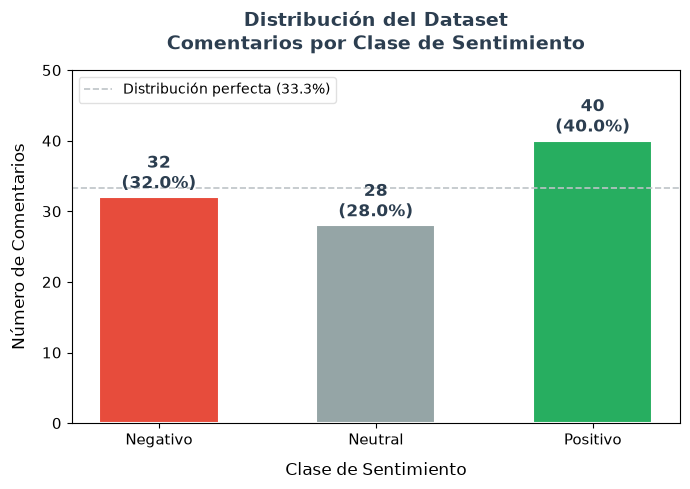

✅ Gráfica guardada como grafica_1_distribucion.png


In [23]:
conteo = df['sentimiento'].value_counts().reindex(CLASES_ORDEN)

fig, ax = plt.subplots(figsize=(7, 5))

barras = ax.bar(
    conteo.index,
    conteo.values,
    color=LISTA_COLORES,
    edgecolor='white',
    linewidth=1.5,
    width=0.55,
)

# Etiquetas sobre cada barra
for barra, valor in zip(barras, conteo.values):
    pct = valor / len(df) * 100
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.5,
        f'{valor}\n({pct:.1f}%)',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold', color='#2C3E50'
    )

ax.set_title(
    'Distribución del Dataset\nComentarios por Clase de Sentimiento',
    fontsize=14, fontweight='bold', color='#2C3E50', pad=15
)
ax.set_xlabel('Clase de Sentimiento', fontsize=12, labelpad=10)
ax.set_ylabel('Número de Comentarios', fontsize=12, labelpad=10)
ax.set_ylim(0, max(conteo.values) * 1.25)
ax.tick_params(labelsize=11)

# Línea de referencia en la distribución perfecta
ax.axhline(
    y=len(df)/3, color='#BDC3C7', linestyle='--', linewidth=1.2,
    label=f'Distribución perfecta (33.3%)'
)
ax.legend(fontsize=10, framealpha=0.6)

plt.tight_layout()
plt.savefig('grafica_1_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfica guardada como grafica_1_distribucion.png')

---
## 🔢 Visualización 2 — Vectorización: el Texto se Convierte en Números

El modelo nunca "lee" texto. Lo que hace es convertir cada comentario en una fila de números:  
**0** si esa palabra no aparece en el comentario, y **mayor a 0** si sí aparece (según su frecuencia).  
Este heatmap muestra esa tabla de números para 10 comentarios de ejemplo y 15 palabras clave — es la misma tabla gigante que el modelo usa para aprender.

Palabras reconocidas en el vocabulario: ['terrible', 'flojo', 'decepcionante', 'desastre', 'partido', 'gol', 'victoria', 'brillante', 'espectacular', 'clase']


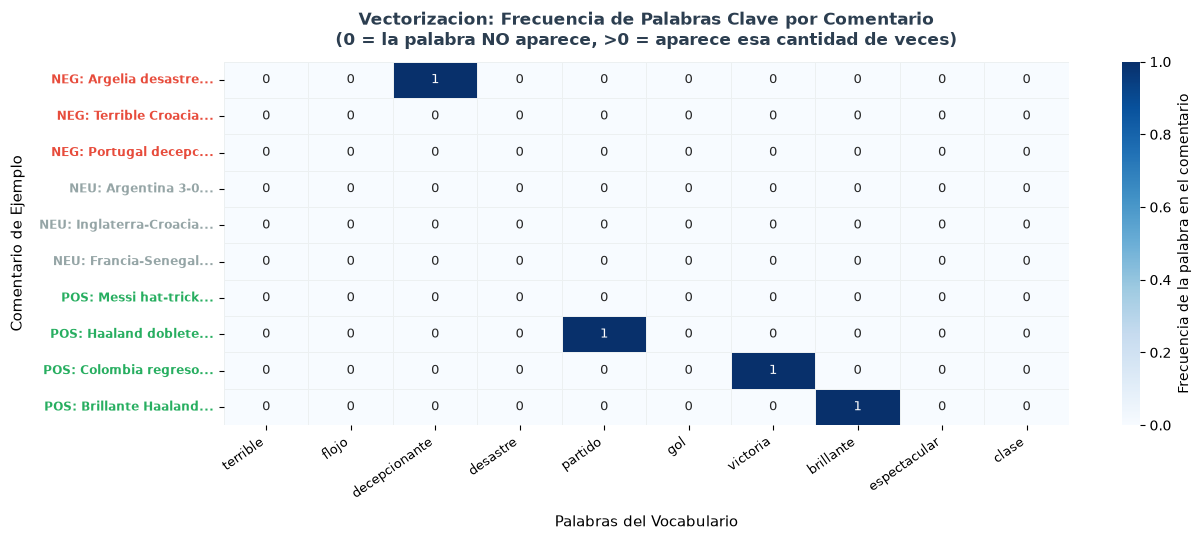

✅ Grafica guardada como grafica_2_vectorizacion.png


In [24]:
# idx_muestras: lista de INDICES DE FILA del dataset original (0 a 99).
# El CSV tiene 100 comentarios numerados desde 0; cada numero aqui
# indica que fila queremos mostrar en el heatmap.
# Se eligen 10 filas manualmente, asegurandose de incluir ejemplos
# de las tres clases para que la comparacion visual sea representativa.
# (No se muestran las 100 filas porque el heatmap seria ilegible.)
idx_muestras = [
    42, 46, 56,    # filas del CSV que contienen comentarios NEGATIVOS
    73, 78, 81,    # filas del CSV que contienen comentarios NEUTRALES
    0,  7, 13, 36, # filas del CSV que contienen comentarios POSITIVOS
]
labels_muestras = [
    'NEG: Argelia desastre...',
    'NEG: Terrible Croacia...',
    'NEG: Portugal decepc...',
    'NEU: Argentina 3-0...',
    'NEU: Inglaterra-Croacia...',
    'NEU: Francia-Senegal...',
    'POS: Messi hat-trick...',
    'POS: Haaland doblete...',
    'POS: Colombia regreso...',
    'POS: Brillante Haaland...',
]

# Palabras clave a mostrar (interesantes para el análisis de sentimiento)
palabras_interes = [
    'terrible', 'pesimo', 'pesima', 'flojo', 'decepcionante', 'desastre',
    'partido', 'gol', 'victoria',
    'brillante', 'increible', 'espectacular', 'actuacion', 'goleo', 'clase'
]

# Filtrar solo las palabras que están en el vocabulario del vectorizador
vocab = vectorizador.vocabulary_
palabras_validas = [p for p in palabras_interes if p in vocab]
print(f'Palabras reconocidas en el vocabulario: {palabras_validas}')

# Construir sub-matriz
indices_cols = [vocab[p] for p in palabras_validas]
X_denso = X.toarray()
sub_matrix = X_denso[idx_muestras, :][:, indices_cols]

fig, ax = plt.subplots(figsize=(13, 5.5))

cmap_custom = sns.color_palette('Blues', as_cmap=True)

hm = sns.heatmap(
    sub_matrix,
    annot=True,
    fmt='.0f',
    cmap=cmap_custom,
    xticklabels=palabras_validas,
    yticklabels=labels_muestras,
    linewidths=0.5,
    linecolor='#ECF0F1',
    ax=ax,
    annot_kws={'size': 9},
    cbar_kws={'label': 'Frecuencia de la palabra en el comentario'},
)

# Colorear etiquetas Y según clase
colores_y = (
    [COLORES['Negativo']] * 3 +
    [COLORES['Neutral']]  * 3 +
    [COLORES['Positivo']] * 4
)
for tick, color in zip(ax.get_yticklabels(), colores_y):
    tick.set_color(color)
    tick.set_fontweight('bold')

ax.set_title(
    'Vectorizacion: Frecuencia de Palabras Clave por Comentario\n'
    '(0 = la palabra NO aparece, >0 = aparece esa cantidad de veces)',
    fontsize=12, fontweight='bold', color='#2C3E50', pad=12
)
ax.set_xlabel('Palabras del Vocabulario', fontsize=11, labelpad=10)
ax.set_ylabel('Comentario de Ejemplo', fontsize=11, labelpad=10)
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=8.5)
plt.tight_layout()
plt.savefig('grafica_2_vectorizacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafica guardada como grafica_2_vectorizacion.png')

---
## 🧠 Visualización 3 — Lo Que el Modelo "Aprendió": Palabras por Clase

Durante el entrenamiento, Naive Bayes calculó **qué tan asociada está cada palabra con cada clase**.  
Este gráfico muestra las **10 palabras más características** de cada sentimiento — es literalmente lo que el modelo "recuerda" de los datos de entrenamiento.  
Cuando llega un comentario nuevo, estas son las palabras que más influyen en la decisión.

> ℹ️ Esta gráfica usa `modelo_final` (entrenado con el **100%** de los datos), igual que la Visualización 5.  
> Así los pesos de las palabras son **exactamente los mismos** en ambas gráficas.

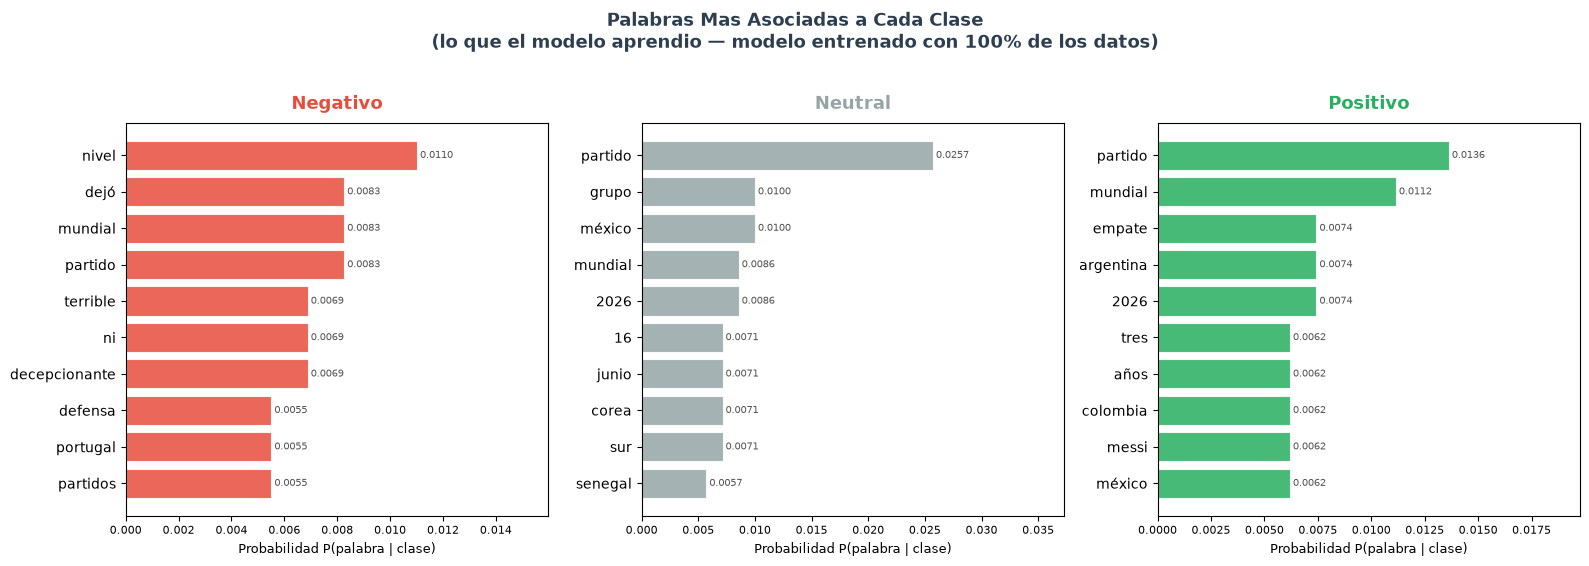

✅ Grafica guardada como grafica_3_palabras_por_clase.png


In [25]:
# USAMOS modelo_final (100% datos) para que los pesos coincidan
# exactamente con los de la Visualización 5 (votos de cada palabra)
nombres_features = vectorizador.get_feature_names_out()
TOP_N = 10

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle(
    'Palabras Mas Asociadas a Cada Clase\n(lo que el modelo aprendio — modelo entrenado con 100% de los datos)',
    fontsize=13, fontweight='bold', color='#2C3E50', y=1.02
)

for ax, clase in zip(axes, modelo_final.classes_):
    idx_clase = list(modelo_final.classes_).index(clase)
    log_probs = modelo_final.feature_log_prob_[idx_clase]

    # Top N palabras con mayor log-probabilidad
    top_idx = np.argsort(log_probs)[-TOP_N:][::-1]
    top_palabras = nombres_features[top_idx]
    top_probs    = np.exp(log_probs[top_idx])   # convertir a probabilidad real

    color_clase = COLORES[clase]
    barras = ax.barh(
        range(TOP_N), top_probs[::-1],
        color=color_clase, alpha=0.85, edgecolor='white', linewidth=0.8
    )
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top_palabras[::-1], fontsize=10)

    # Valores al final de cada barra
    for i, (barra, val) in enumerate(zip(barras, top_probs[::-1])):
        ax.text(
            barra.get_width() + max(top_probs) * 0.01,
            barra.get_y() + barra.get_height() / 2,
            f'{val:.4f}',
            va='center', fontsize=7.5, color='#555'
        )

    ax.set_title(clase, fontsize=13, fontweight='bold', color=color_clase, pad=10)
    ax.set_xlabel('Probabilidad P(palabra | clase)', fontsize=9)
    ax.set_xlim(0, max(top_probs) * 1.45)
    ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig('grafica_3_palabras_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafica guardada como grafica_3_palabras_por_clase.png')

---
## ✅ Visualización 4 — Matriz de Confusión (mejorada)

La matriz de confusión muestra **cuántas veces acertó y cuántas se equivocó** el modelo al clasificar los 20 comentarios de prueba.  
La diagonal principal (de arriba-izquierda a abajo-derecha) son los aciertos: cuanto más oscura, mejor.  
Los valores fuera de la diagonal son errores: por ejemplo, si una celda fuera de la diagonal tiene número, el modelo confundió una clase con otra.

> ℹ️ Esta gráfica usa `modelo` (entrenado con el **80%** de los datos, evaluado en el 20% restante).  
> Es la métrica honesta de desempeño — el modelo nunca vio estos 20 comentarios antes.

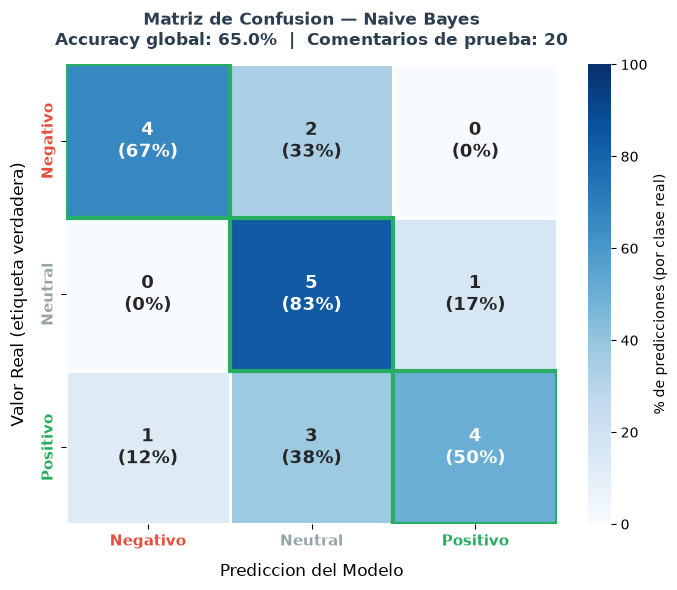

✅ Grafica guardada como grafica_4_matriz_confusion.png


In [26]:
matriz = confusion_matrix(y_test, y_pred, labels=CLASES_ORDEN)
total_por_clase_real = matriz.sum(axis=1, keepdims=True)
matriz_pct = matriz / total_por_clase_real * 100   # porcentaje por fila

# Etiquetas combinadas: conteo + porcentaje
etiquetas = np.empty_like(matriz, dtype=object)
for i in range(matriz.shape[0]):
    for j in range(matriz.shape[1]):
        etiquetas[i, j] = f'{matriz[i, j]}\n({matriz_pct[i, j]:.0f}%)'

fig, ax = plt.subplots(figsize=(7, 6))

# Heatmap base (mapeado sobre porcentajes para mejor contraste visual)
sns.heatmap(
    matriz_pct,
    annot=etiquetas,
    fmt='',
    cmap='Blues',
    xticklabels=CLASES_ORDEN,
    yticklabels=CLASES_ORDEN,
    linewidths=1,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 13, 'weight': 'bold'},
    vmin=0, vmax=100,
    cbar_kws={'label': '% de predicciones (por clase real)'}
)

# Bordes de celdas de la diagonal en verde
for i in range(len(CLASES_ORDEN)):
    ax.add_patch(plt.Rectangle(
        (i, i), 1, 1,
        fill=False, edgecolor=COLORES['Positivo'], lw=3
    ))

# Colorear etiquetas de ejes
for tick, clase in zip(ax.get_xticklabels(), CLASES_ORDEN):
    tick.set_color(COLORES[clase])
    tick.set_fontweight('bold')
    tick.set_fontsize(11)
for tick, clase in zip(ax.get_yticklabels(), CLASES_ORDEN):
    tick.set_color(COLORES[clase])
    tick.set_fontweight('bold')
    tick.set_fontsize(11)

acc = accuracy_score(y_test, y_pred)
ax.set_title(
    f'Matriz de Confusion — Naive Bayes\n'
    f'Accuracy global: {acc:.1%}  |  Comentarios de prueba: {len(y_test)}',
    fontsize=12, fontweight='bold', color='#2C3E50', pad=14
)
ax.set_xlabel('Prediccion del Modelo', fontsize=12, labelpad=10)
ax.set_ylabel('Valor Real (etiqueta verdadera)', fontsize=12, labelpad=10)

plt.tight_layout()
plt.savefig('grafica_4_matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafica guardada como grafica_4_matriz_confusion.png')

---
## 🗳️ Visualización 5 — El "Voto" de Cada Palabra en una Predicción Nueva

Esta es la visualización más importante: muestra exactamente **cómo toma la decisión el modelo**.  
Para un comentario nuevo, cada palabra "vota" por una clase usando su probabilidad aprendida.  
Al final, Naive Bayes **multiplica todos los votos** y la clase con el producto más grande gana.

> 💡 **Truco**: como multiplicar muchos decimales pequeños puede dar números ridículamente chicos, el modelo usa **logaritmos** (que convierten multiplicaciones en sumas). El resultado es el mismo: gana quien acumula más.

> ℹ️ Esta gráfica usa `modelo_final` (entrenado con el **100%** de los datos), igual que la Visualización 3.  
> Por eso los pesos de las palabras son los **mismos** en ambas gráficas.

Palabras reconocidas en el vocabulario: ['terrible', 'flojo', 'nivel', 'equipo']


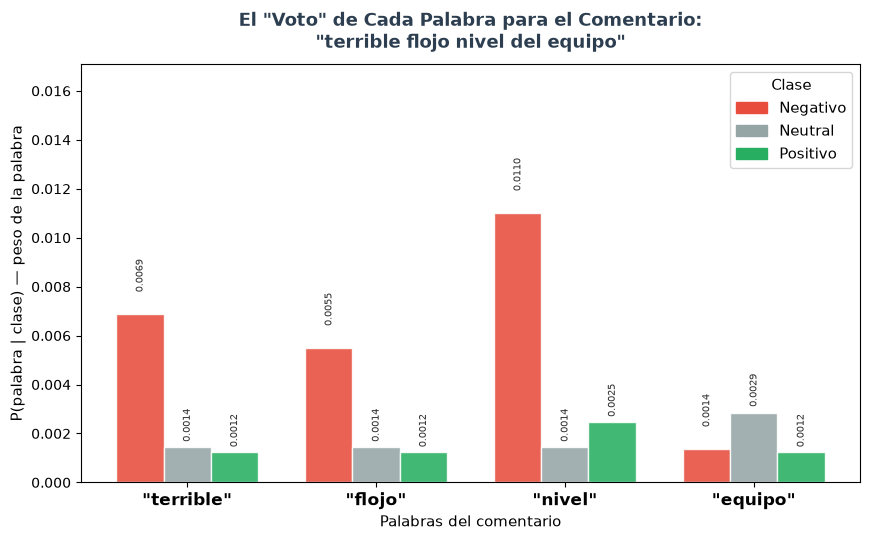


  CALCULO BAYESIANO COMPLETO

  Negativo:
    Score bruto    = 1.84e-10
    Probabilidad   = 97.8% <- GANADORA

  Neutral:
    Score bruto    = 2.33e-12
    Probabilidad   = 1.2%

  Positivo:
    Score bruto    = 1.89e-12
    Probabilidad   = 1.0%


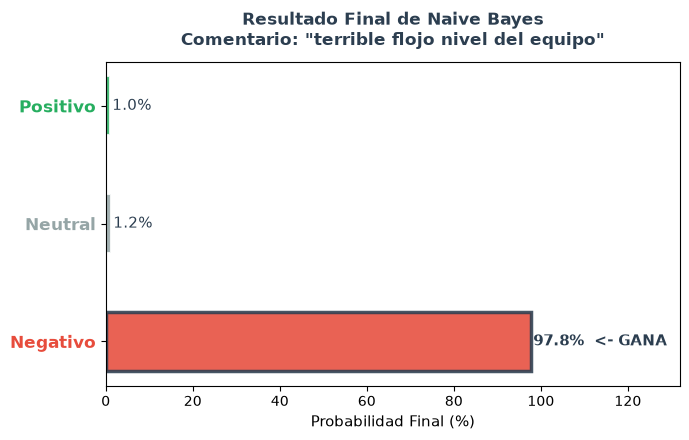


✅ Graficas guardadas como grafica_5a_votos.png y grafica_5b_resultado_final.png


In [27]:
comentario_ejemplo = 'terrible flojo nivel del equipo'

# ── Peso de cada palabra por clase (probabilidad real, no log) ──
nombres = vectorizador.get_feature_names_out()

# Tokenizar manualmente el comentario de ejemplo
palabras_comentario_raw = comentario_ejemplo.lower().split()
palabras_en_vocab = [
    p for p in palabras_comentario_raw if p in vectorizador.vocabulary_
]
print(f'Palabras reconocidas en el vocabulario: {palabras_en_vocab}')

# Probabilidades por palabra y clase (usando modelo_final)
datos_votos = {}
for palabra in palabras_en_vocab:
    col_idx = vectorizador.vocabulary_[palabra]
    datos_votos[palabra] = {
        clase: np.exp(modelo_final.feature_log_prob_[
            list(modelo_final.classes_).index(clase)
        ][col_idx])
        for clase in CLASES_ORDEN
    }

# ── GRÁFICA DE BARRAS AGRUPADAS ──────────────────────────────────
x_pos = np.arange(len(palabras_en_vocab))
ancho  = 0.25

fig, ax = plt.subplots(figsize=(max(8, len(palabras_en_vocab) * 2.2), 5.5))

for i, clase in enumerate(CLASES_ORDEN):
    valores = [datos_votos[p][clase] for p in palabras_en_vocab]
    barras_cls = ax.bar(
        x_pos + i * ancho, valores,
        width=ancho, label=clase,
        color=COLORES[clase], alpha=0.88, edgecolor='white'
    )
    for barra, val in zip(barras_cls, valores):
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height() + max(valores) * 0.08,
            f'{val:.4f}',
            ha='center', va='bottom', fontsize=7.5, color='#333',
            rotation=90
        )

ax.set_xticks(x_pos + ancho)
ax.set_xticklabels(
    [f'"{p}"' for p in palabras_en_vocab],
    fontsize=12, fontweight='bold'
)
ax.set_ylabel('P(palabra | clase) — peso de la palabra', fontsize=11)
ax.set_xlabel('Palabras del comentario', fontsize=11)
ax.set_title(
    f'El "Voto" de Cada Palabra para el Comentario:\n"{comentario_ejemplo}"',
    fontsize=13, fontweight='bold', color='#2C3E50', pad=12
)
ax.legend(
    handles=[
        mpatches.Patch(color=COLORES[c], label=c) for c in CLASES_ORDEN
    ],
    fontsize=11, title='Clase', title_fontsize=11
)
ax.set_ylim(0, max(max(datos_votos[p][c] for p in palabras_en_vocab) for c in CLASES_ORDEN) * 1.55)
plt.tight_layout()
plt.savefig('grafica_5a_votos.png', dpi=150, bbox_inches='tight')
plt.show()

# ── CÁLCULO FINAL: PRIOR × PRODUCTO DE PESOS ─────────────────────
print('\n' + '='*62)
print('  CALCULO BAYESIANO COMPLETO')
print('='*62)

priors = np.exp(modelo_final.class_log_prior_)
priors_dict = dict(zip(modelo_final.classes_, priors))

scores_raw = {}
for clase in CLASES_ORDEN:
    prior = priors_dict[clase]
    producto = prior
    for p in palabras_en_vocab:
        w = datos_votos[p][clase]
        producto *= w
    scores_raw[clase] = producto

total = sum(scores_raw.values())
proba_final = {k: v / total for k, v in scores_raw.items()}
ganadora = max(proba_final, key=proba_final.get)

for clase in CLASES_ORDEN:
    marcador = ' <- GANADORA' if clase == ganadora else ''
    print(f'\n  {clase}:')
    print(f'    Score bruto    = {scores_raw[clase]:.2e}')
    print(f'    Probabilidad   = {proba_final[clase]:.1%}{marcador}')

# ── GRÁFICA DE RESULTADO FINAL ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))

clases_ord  = CLASES_ORDEN
probs_ord   = [proba_final[c] * 100 for c in clases_ord]
colores_res = [COLORES[c] for c in clases_ord]

barras_res = ax.barh(
    clases_ord, probs_ord,
    color=colores_res, alpha=0.88, edgecolor='white', linewidth=1.5,
    height=0.5
)

for barra, clase, val in zip(barras_res, clases_ord, probs_ord):
    peso_extra = 'bold' if clase == ganadora else 'normal'
    if clase == ganadora:
        barra.set_edgecolor('#2C3E50')
        barra.set_linewidth(2.5)
    ax.text(
        val + 0.5, barra.get_y() + barra.get_height() / 2,
        f'{val:.1f}%' + ('  <- GANA' if clase == ganadora else ''),
        va='center', fontsize=11, fontweight=peso_extra, color='#2C3E50'
    )

ax.set_xlim(0, max(probs_ord) * 1.35)
ax.set_xlabel('Probabilidad Final (%)', fontsize=11)
ax.set_title(
    f'Resultado Final de Naive Bayes\n'
    f'Comentario: "{comentario_ejemplo}"',
    fontsize=12, fontweight='bold', color='#2C3E50', pad=12
)
ax.tick_params(axis='y', labelsize=12)
for tick, clase in zip(ax.get_yticklabels(), clases_ord):
    tick.set_color(COLORES[clase])
    tick.set_fontweight('bold')

plt.tight_layout()
plt.savefig('grafica_5b_resultado_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Graficas guardadas como grafica_5a_votos.png y grafica_5b_resultado_final.png')

---
## 🎮 Visualización 6 — Demo Interactiva: Prueba Tu Propio Comentario

¡Aquí puedes probar el modelo con cualquier comentario que se te ocurra!  
Solo cambia el texto en la variable `MI_COMENTARIO`, ejecuta la celda, y verás en segundos qué clase predice el modelo y con qué porcentaje de confianza.  
Prueba con comentarios ambiguos o creativos para ver si el modelo acierta. 🧪

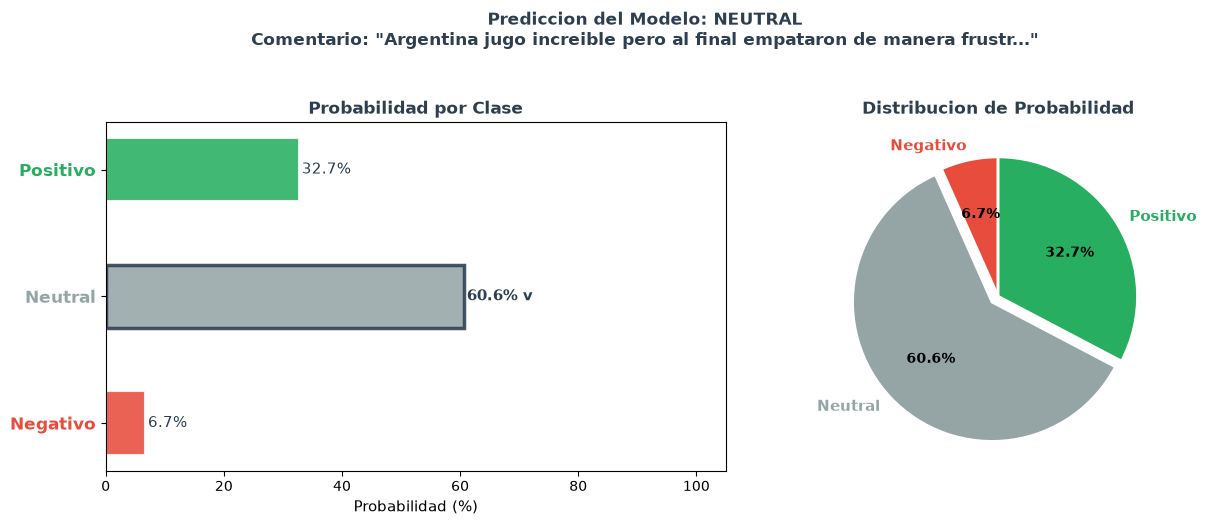


El modelo clasifica este comentario como: Neutral
   Confianza: 60.6%

   Probabilidades completas:
   Negativo   █                              6.7%
   Neutral    ██████████████████             60.6%
   Positivo   █████████                      32.7%


In [28]:
# ✏️  CAMBIA ESTE COMENTARIO Y VUELVE A EJECUTAR LA CELDA
MI_COMENTARIO = "Argentina jugo increible pero al final empataron de manera frustrante"

# ── Predicción ────────────────────────────────────────────────
vec_nuevo      = vectorizador.transform([MI_COMENTARIO])
prediccion     = modelo_final.predict(vec_nuevo)[0]
probabilidades = modelo_final.predict_proba(vec_nuevo)[0]
proba_dict     = dict(zip(modelo_final.classes_, probabilidades))

# Ordenar según CLASES_ORDEN
probs_ordenadas = [proba_dict[c] * 100 for c in CLASES_ORDEN]

# ── Figura ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5),
                          gridspec_kw={'width_ratios': [1.1, 1]})

# — Gráfica de barras horizontales (izquierda) —
ax1 = axes[0]
barras_demo = ax1.barh(
    CLASES_ORDEN, probs_ordenadas,
    color=[COLORES[c] for c in CLASES_ORDEN],
    alpha=0.88, edgecolor='white', linewidth=1.5, height=0.5
)
for barra, clase, val in zip(barras_demo, CLASES_ORDEN, probs_ordenadas):
    if clase == prediccion:
        barra.set_edgecolor('#2C3E50')
        barra.set_linewidth(2.5)
    ax1.text(
        val + 0.5, barra.get_y() + barra.get_height() / 2,
        f'{val:.1f}%' + (' v' if clase == prediccion else ''),
        va='center', fontsize=11,
        fontweight='bold' if clase == prediccion else 'normal',
        color='#2C3E50'
    )

ax1.set_xlim(0, 105)
ax1.set_xlabel('Probabilidad (%)', fontsize=11)
ax1.set_title('Probabilidad por Clase', fontsize=12, fontweight='bold', color='#2C3E50')
for tick, clase in zip(ax1.get_yticklabels(), CLASES_ORDEN):
    tick.set_color(COLORES[clase])
    tick.set_fontweight('bold')
    tick.set_fontsize(12)

# — Gráfica de pastel (derecha) —
ax2 = axes[1]
explode = [0.06 if c == prediccion else 0 for c in CLASES_ORDEN]
wedges, texts, autotexts = ax2.pie(
    probs_ordenadas,
    labels=CLASES_ORDEN,
    colors=[COLORES[c] for c in CLASES_ORDEN],
    autopct='%1.1f%%',
    startangle=90,
    explode=explode,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11},
)
for text, clase in zip(texts, CLASES_ORDEN):
    text.set_color(COLORES[clase])
    text.set_fontweight('bold')
for atext in autotexts:
    atext.set_fontsize(10)
    atext.set_fontweight('bold')
ax2.set_title('Distribucion de Probabilidad', fontsize=12, fontweight='bold', color='#2C3E50')

# — Título principal —
fig.suptitle(
    f'Prediccion del Modelo: {prediccion.upper()}\n'
    f'Comentario: "{MI_COMENTARIO[:65]}{"..." if len(MI_COMENTARIO) > 65 else ""}"',
    fontsize=12, fontweight='bold', color='#2C3E50', y=1.04
)

plt.tight_layout()
plt.savefig('grafica_6_demo_interactiva.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nEl modelo clasifica este comentario como: {prediccion}')
print(f'   Confianza: {proba_dict[prediccion]:.1%}')
print('\n   Probabilidades completas:')
for clase in CLASES_ORDEN:
    barra_txt = '█' * int(proba_dict[clase] * 30)
    print(f'   {clase:10s} {barra_txt:<30s} {proba_dict[clase]:.1%}')

---
## 📁 Resumen: Archivos Generados

Al ejecutar todas las celdas, se generan estos archivos en la misma carpeta del notebook:

| Archivo | Visualización | Modelo usado |
|---|---|---|
| `grafica_1_distribucion.png` | Distribución del dataset | — |
| `grafica_2_vectorizacion.png` | Heatmap de vectorización | — |
| `grafica_3_palabras_por_clase.png` | Top 10 palabras por clase | `modelo_final` (100%) |
| `grafica_4_matriz_confusion.png` | Matriz de confusión mejorada | `modelo` (80/20) |
| `grafica_5a_votos.png` | Votos de cada palabra | `modelo_final` (100%) |
| `grafica_5b_resultado_final.png` | Resultado bayesiano final | `modelo_final` (100%) |
| `grafica_6_demo_interactiva.png` | Demo con comentario personalizado | `modelo_final` (100%) |

> 💡 **Para la presentación:** puedes importar cualquiera de estas imágenes directamente en PowerPoint con **Insertar → Imagen → Este dispositivo**.

---

### ¿Por qué hay dos modelos?

| Modelo | Datos | Para qué sirve |
|---|---|---|
| `modelo` | 80% (`X_train`) | Evaluar el desempeño de forma honesta (matriz de confusión) |
| `modelo_final` | 100% (`X`) | Predicciones reales y visualizaciones de palabras |

Los pesos de las palabras difieren ligeramente entre ambos porque `modelo_final` aprendió de 20 comentarios adicionales.  
Por eso las Visualizaciones 3 y 5 usan **el mismo modelo** (`modelo_final`), garantizando que los números sean consistentes.